# CAP4453 — Assignment 3: Transfer Learning (ResNet-18 → CIFAR-10)

**What you will do:** Use an ImageNet-pretrained **ResNet-18** and perform **last-layers fine-tuning** on CIFAR-10 by **freezing the backbone** and training **only the classifier head**.

**Rules for this assignment**
- Select the **best checkpoint using validation accuracy**.
- Run **test evaluation once** using the best validation checkpoint.

You will report:
- Best **validation accuracy**
- Final **test accuracy**
- Training curves: **train/val loss** and **train/val accuracy**
- A small set of **misclassified examples** (with predicted + true labels)


## 0) Setup

In [1]:
# ====== Imports (provided) ======
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights

import matplotlib.pyplot as plt

# (Optional) If you want nicer progress bars:
# from tqdm.auto import tqdm


In [2]:
# ====== Reproducibility + device (provided) ======
SEED = 4453
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
# ====== Fixed training configuration (do NOT tune) ======
NUM_CLASSES = 10
INPUT_SIZE = 224

# Keep this CPU-friendly:
BATCH_SIZE = 128 if torch.cuda.is_available() else 32
EPOCHS = 10 if torch.cuda.is_available() else 5

LR = 1e-3
WEIGHT_DECAY = 1e-4

NUM_WORKERS = 2  # set to 0 if you have DataLoader issues on your machine
PIN_MEMORY = torch.cuda.is_available()

print(dict(BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS, LR=LR, WEIGHT_DECAY=WEIGHT_DECAY, INPUT_SIZE=INPUT_SIZE))


{'BATCH_SIZE': 128, 'EPOCHS': 10, 'LR': 0.001, 'WEIGHT_DECAY': 0.0001, 'INPUT_SIZE': 224}


## 1) Data transforms

Create:
- `train_transform`: resize to `INPUT_SIZE`, apply **light augmentation**, then ImageNet normalization
- `eval_transform`: resize to `INPUT_SIZE`, **no random ops**, then ImageNet normalization

**Hint:** `ResNet18_Weights.IMAGENET1K_V1.meta["mean"]` and `["std"]` provide ImageNet mean/std.


In [ ]:
# ====== STUDENT TODO: define transforms ======
weights = ResNet18_Weights.IMAGENET1K_V1
IMAGENET_MEAN = weights.transforms().mean
IMAGENET_STD = weights.transforms().std

# STUDENT TODO:
# 1) Build train_transform with:
#    - transforms.Resize((INPUT_SIZE, INPUT_SIZE))
#    - at least one light augmentation (e.g., RandomHorizontalFlip, RandomCrop, ColorJitter)
#    - transforms.ToTensor()
#    - transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
#
# 2) Build eval_transform with:
#    - transforms.Resize((INPUT_SIZE, INPUT_SIZE))
#    - transforms.ToTensor()
#    - transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

# Image preprocessing
train_transform = transforms.Compose([transforms.Resize((INPUT_SIZE, INPUT_SIZE)), transforms.RandomHorizontalFlip(p=0.5), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
eval_transform = transforms.Compose([transforms.Resize((INPUT_SIZE, INPUT_SIZE)), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

# Quick sanity check (leave this as-is):
print("train_transform:", train_transform)
print("eval_transform:", eval_transform)


train_transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
eval_transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 2) Dataset and train/val split

Load CIFAR-10 and create a **train/validation split** from the official training set.

**Important:** Validation must be **deterministic** (no random augmentation).  
A simple approach is to:
1. Load the CIFAR-10 train set twice (once with `train_transform`, once with `eval_transform`).
2. Use the **same index split** for both.


In [5]:
# ====== STUDENT TODO: load datasets and split indices ======
DATA_ROOT = "./data"

# STUDENT TODO:
# - Create two CIFAR-10 train datasets:
#   train_full_aug uses train_transform
#   train_full_eval uses eval_transform
# - Create the CIFAR-10 test dataset using eval_transform

train_full_aug = datasets.CIFAR10(root=DATA_ROOT, train=True, download=True, transform=train_transform)   # TODO
train_full_eval = datasets.CIFAR10(root=DATA_ROOT,train=True,download=True, transform=eval_transform)  # TODO
test_dataset = datasets.CIFAR10(root=DATA_ROOT, train=False, download=True,transform=eval_transform)    # TODO

# STUDENT TODO:
# Create a deterministic split: e.g., 45k train / 5k val
num_total =  len(train_full_aug)
num_val = 5000
num_train = num_total - num_val

# Create indices with a fixed seed
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(num_total, generator=g).tolist()
train_idx = perm[:num_train]  # TODO
val_idx = perm[num_train:]    # TODO

# Build subsets:
train_dataset =Subset(train_full_aug, train_idx)
val_dataset = Subset(train_full_eval, val_idx)

print("train/val/test sizes:", len(train_dataset), len(val_dataset), len(test_dataset))


100%|██████████| 170M/170M [00:14<00:00, 12.1MB/s] 


train/val/test sizes: 45000 5000 10000


## 3) DataLoaders

Create `train_loader`, `val_loader`, and `test_loader`.

- Use `shuffle=True` for training only.
- Use `shuffle=False` for validation and test.


In [ ]:
# ====== STUDENT TODO: build dataloaders ======
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print("Loaders ready.")


Loaders ready.


## 4) Model: ResNet-18 (freeze backbone, train head)

Implement `build_resnet18_head_only()`:

1. Load ImageNet-pretrained ResNet-18  
2. Replace final `fc` layer to output 10 classes  
3. Freeze **all backbone parameters**  
4. Ensure only the classifier head parameters are trainable


In [7]:
from torchvision.models import resnet18, ResNet18_Weights

# ====== STUDENT TODO: build model (head-only fine-tuning) ======
def build_resnet18_head_only(num_classes: int):
    """Return an ImageNet-pretrained ResNet-18 with a new classifier head.

    Requirements:
    - Use pretrained ImageNet weights
    - Replace final fc layer -> num_classes outputs
    - Freeze backbone (everything except the new fc)
    """
    # ✅ provided: load pretrained resnet18 (ImageNet)
    weights = ResNet18_Weights.IMAGENET1K_V1
    model = resnet18(weights=weights)

    # TODO: replace final layer
    in_features = model.fc.in_features
    model.fc = torch.nn.Linear(in_features, num_classes)

    # TODO: freeze backbone parameters (everything except model.fc)
    for name, p in model.named_parameters():
        if not name.startswith("fc."):
            p.requires_grad = False

    return model

model = build_resnet18_head_only(NUM_CLASSES).to(device)
# Sanity check: print trainable parameter names and count
trainable = [(n, p.numel()) for n, p in model.named_parameters() if p.requires_grad]
print("Trainable tensors:", [n for n, _ in trainable])
print("Trainable params:", sum(x for _, x in trainable))


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 239MB/s]


Trainable tensors: ['fc.weight', 'fc.bias']
Trainable params: 5130


## 5) Loss and optimizer (fixed settings)

Use:
- Cross-entropy loss
- Adam optimizer
- Optimize **only** trainable parameters (`requires_grad=True`)


In [8]:
# ====== STUDENT TODO: define criterion and optimizer ======
criterion = nn.CrossEntropyLoss()

# Collect only trainable parameters
trainable_params = [p for p in model.parameters() if p.requires_grad]

optimizer = optim.Adam(trainable_params, lr=LR, weight_decay=WEIGHT_DECAY)

print("Optimizer ready. Trainable param tensors:", len(trainable_params))


Optimizer ready. Trainable param tensors: 2


## 6) Training and evaluation utilities

Implement:
- `compute_accuracy(logits, targets)`
- `train_one_epoch(...)` → returns `(avg_loss, avg_acc)`
- `evaluate(...)` → returns `(avg_loss, avg_acc)` (with `torch.no_grad()`)

**Tip:** Accuracy = correct / total, where `pred = logits.argmax(dim=1)`.


In [9]:
# ====== STUDENT TODO: training utilities ======
def compute_accuracy(logits: torch.Tensor, targets: torch.Tensor) -> float:
    """Return accuracy for a batch."""
    return (logits.argmax(dim=1) == targets).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch. Return (avg_loss, avg_acc)."""
    model.train()

    # TODO: initialize running sums
    # TODO: loop over loader:
    total_loss = 0
    num_correct = 0
    total = 0
    for x,y in loader:
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        pred = logits.argmax(dim=1)
        num_correct += (pred == y).sum().item()
        total_loss += loss.item() * x.size(0)
        total += x.size(0)
    avg_loss = total_loss / total  
    avg_acc = num_correct / total   
    return avg_loss, avg_acc

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate. Return (avg_loss, avg_acc)."""
    model.eval()
    loss = 0
    correct = 0
    total = 0
    for x,y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        predictions = logits.argmax(dim=1)
        correct += (predictions == y).sum().item()
        loss += criterion(logits, y).item() * x.size(0)
        total += x.size(0)
    avg_loss = loss / total
    avg_acc = correct / total
    return avg_loss, avg_acc


## 7) Single-run training loop + best checkpoint by validation accuracy

Run training for `EPOCHS` (one run only).  
After each epoch:
- compute train loss/acc
- compute val loss/acc
- update curves
- **save checkpoint** if validation accuracy improves

Save path: `best_resnet18_head_cifar10.pt`


In [10]:
# ====== STUDENT TODO: training loop + checkpointing ======
BEST_CKPT_PATH = "best_resnet18_head_cifar10.pt"

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_acc = -1.0
best_epoch = -1

for epoch in range(1, EPOCHS + 1):
    # TODO: call train_one_epoch
    train_loss, train_acc = train_one_epoch(model=model, loader=train_loader, optimizer=optimizer, criterion=criterion, device=device)

    # TODO: call evaluate on val
    val_loss, val_acc = evaluate(model=model, loader=val_loader, criterion=criterion, device=device)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save({"model_state": model.state_dict(), "epoch": epoch, "val_acc": val_acc}, BEST_CKPT_PATH)

    
    # TODO: append to history lists
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train loss={train_loss:.4f} acc={train_acc:.4f} | "
          f"val loss={val_loss:.4f} acc={val_acc:.4f}")

print("Best epoch:", best_epoch, "Best val acc:", best_val_acc)
print("Saved best checkpoint to:", BEST_CKPT_PATH)


Epoch 01/10 | train loss=0.9251 acc=0.7117 | val loss=0.6451 acc=0.7852
Epoch 02/10 | train loss=0.6366 acc=0.7861 | val loss=0.5925 acc=0.7986
Epoch 03/10 | train loss=0.5931 acc=0.7964 | val loss=0.5609 acc=0.8066
Epoch 04/10 | train loss=0.5739 acc=0.8015 | val loss=0.5467 acc=0.8126
Epoch 05/10 | train loss=0.5669 acc=0.8049 | val loss=0.5619 acc=0.8038
Epoch 06/10 | train loss=0.5551 acc=0.8075 | val loss=0.5450 acc=0.8066
Epoch 07/10 | train loss=0.5539 acc=0.8096 | val loss=0.5333 acc=0.8136
Epoch 08/10 | train loss=0.5439 acc=0.8112 | val loss=0.5278 acc=0.8142
Epoch 09/10 | train loss=0.5385 acc=0.8120 | val loss=0.5242 acc=0.8152
Epoch 10/10 | train loss=0.5377 acc=0.8139 | val loss=0.5338 acc=0.8122
Best epoch: 9 Best val acc: 0.8152
Saved best checkpoint to: best_resnet18_head_cifar10.pt


## 8) Plot learning curves

Create:
- Loss curves: train vs val
- Accuracy curves: train vs val


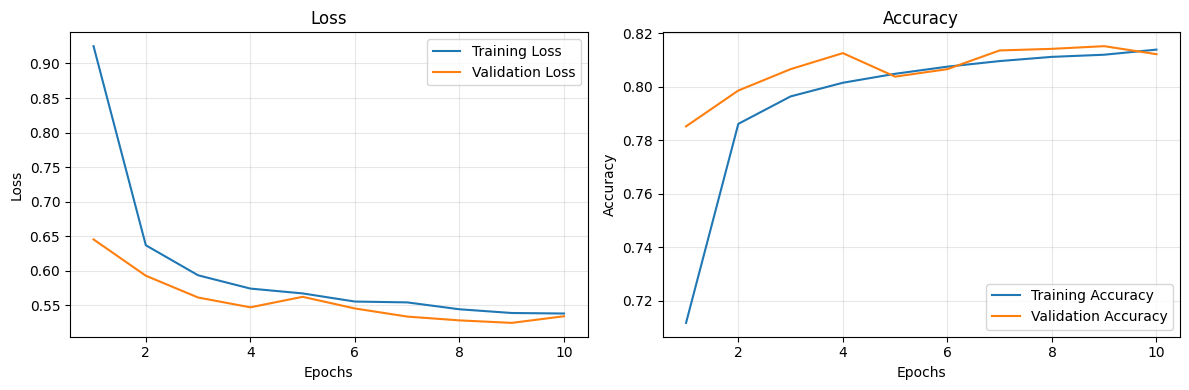

In [11]:
# ====== STUDENT TODO: plot curves ======
# Use history["train_loss"], history["val_loss"], history["train_acc"], history["val_acc"]
epochs = range(1, EPOCHS + 1)
# TODO: plot loss
fig, (axes_loss, axes_acc) = plt.subplots(1, 2, figsize=(12,4))
axes_loss.plot(epochs, history["train_loss"], label="Training Loss")
axes_loss.plot(epochs, history["val_loss"], label="Validation Loss")
axes_loss.set_title("Loss")
axes_loss.set_xlabel("Epochs")
axes_loss.set_ylabel("Loss")
axes_loss.grid(True, alpha=0.3)
axes_loss.legend()

# TODO: plot accuracy
axes_acc.plot(epochs, history["train_acc"], label="Training Accuracy")
axes_acc.plot(epochs, history["val_acc"], label="Validation Accuracy")
axes_acc.set_title("Accuracy")
axes_acc.set_xlabel("Epochs")
axes_acc.set_ylabel("Accuracy")
axes_acc.grid(True, alpha=0.3)
axes_acc.legend()

fig.tight_layout()
fig.savefig("lossacc_curves_transferlearning.pdf", format="pdf")
plt.show()



## 9) Load best checkpoint and evaluate on validation and test 

1. Load `BEST_CKPT_PATH`  
2. Evaluate **validation** and **test**  
3. Report: best val accuracy and final test accuracy


In [14]:
# ====== STUDENT TODO: load checkpoint and evaluate ======
ckpt = torch.load(BEST_CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state"])

# TODO: compute final val metrics
final_val_loss, final_val_acc = evaluate(model=model, criterion=criterion, device=device, loader=train_loader)

# TODO: compute final test metrics (run once)
test_loss, test_acc = evaluate(model=model, criterion=criterion, device=device, loader=test_loader)

print("Final validation accuracy: ", final_val_acc)
print("Final test accuracy: ", test_acc)


Final validation accuracy:  0.8226222222222223
Final test accuracy:  0.812


## 10) Misclassified examples

Show a small set of misclassified **test** images:
- image
- predicted label
- true label

**Tip:** CIFAR-10 class names are in `test_dataset.classes`.


In [13]:
# ====== STUDENT TODO: show misclassified examples ======
# Goal: collect a few misclassified test samples and visualize them.

# Hints:
model.eval()
for x,y in test_loader:
    x = x.todevice(device)
    y = y.todevice(device)
    logits = model(x)
    preds = logits.argmax(dim=1)
    

# - loop over test_loader
# - preds = logits.argmax(dim=1)
# - find where preds != y
# - store (image_tensor, pred, true)
# - visualize with matplotlib (remember to unnormalize if you want correct colors)

misclassified = []  # TODO: fill with tuples (img, pred_idx, true_idx)

# TODO: visualize at least 5


## Submission checklist

Before you submit:
- [ ] Your code trains **only the classifier head** (backbone frozen)
- [ ] You trained and selected the best checkpoint by **validation accuracy**
- [ ] You reported:
  - training and validation curves for loss values and accuracy
  - best validation accuracy
  - final test accuracy (best checkpoint, evaluated once)
- [ ] You included:
  - train/val loss curve
  - train/val accuracy curve
  - ≥ 5 misclassified examples with predicted + true labels
